# Big Data con Apache Spark – Cevichería “La Esquina”
**Curso:** Base de Datos Avanzadas y Big Data (CIIN1021P) · **Grupo 3** · UPN Cajamarca 2026-2

| Fuente | Tipo | Origen |
|---|---|---|
| `fact_ventas.csv` + dimensiones | estructurado | **Data Warehouse** (salida del ETL) |
| `Ventas_Delivery_Apps_Externo.csv` | estructurado, externo | plataformas PedidosYa / Rappi (sin limpiar) |
| `Resenas_Clientes.json` | **semiestructurado** (campos variables, anidados) | reseñas de clientes (misma fuente que MongoDB) |
| `Asistencia_Personal.csv` | estructurado | control de asistencia del personal |

Objetos Spark usados: **RDD**, **DataFrame** y **SparkSQL**. Los gráficos se generan con pandas/matplotlib a partir de `toPandas()` (sin Power BI).

## 1. Instalación y configuración de Apache Spark
En **Google Colab** se instala JDK y se descarga Spark (igual que en clase). En un equipo local con Java 17/21 se usa el paquete `pyspark` (misma versión de Spark).

In [1]:
import sys, os
IN_COLAB = 'google.colab' in sys.modules
SPARK_VERSION = '4.2.0'
if IN_COLAB:
    # 1) JDK 21
    !apt-get install openjdk-21-jdk-headless -qq > /dev/null
    # 2) Apache Spark
    !wget -q https://archive.apache.org/dist/spark/spark-{SPARK_VERSION}/spark-{SPARK_VERSION}-bin-hadoop3.tgz || wget -q https://dlcdn.apache.org/spark/spark-{SPARK_VERSION}/spark-{SPARK_VERSION}-bin-hadoop3.tgz
    !tar -xf spark-{SPARK_VERSION}-bin-hadoop3.tgz
    # 3) librerías de Python
    !pip install -q findspark pyspark==$SPARK_VERSION
    # 4) variables de entorno
    os.environ['JAVA_HOME'] = '/usr/lib/jvm/java-21-openjdk-amd64'
    os.environ['SPARK_HOME'] = f'/content/spark-{SPARK_VERSION}-bin-hadoop3'
    # 5) subir y descomprimir el repositorio en /content/proyecto (Proyecto.zip -> carpeta)
    ROOT = '/content/proyecto'
else:
    ROOT = os.path.abspath('..')      # este cuaderno vive en 06_BigData_Spark/
print('Colab:', IN_COLAB, '| ROOT =', ROOT)

Colab: False | ROOT = /home/claude/repo/Grupo3_CIIN1021P_EF_REPO


In [2]:
try:
    import findspark; findspark.init()
except Exception as e: print('findspark no requerido en local:', e)
from pyspark.sql import SparkSession
spark = (SparkSession.builder.master('local[*]').appName('CevicheriaSpark')
         .config('spark.sql.shuffle.partitions', '8').config('spark.driver.memory', '2g')
         .config('spark.ui.showConsoleProgress', 'false').getOrCreate())
spark.sparkContext.setLogLevel('ERROR')
sc = spark.sparkContext
print('Spark', spark.version, '| Java OK | núcleos disponibles:', sc.defaultParallelism)
spark

findspark no requerido en local: No module named 'findspark'


Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/09/30 04:29:45 WARN Utils: Your hostname, vm, resolves to a loopback address: 127.0.0.1; using 192.0.2.2 instead (on interface eth0)
26/09/30 04:29:45 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address


Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).


/usr/local/lib/python3.12/dist-packages/pyspark/testing/utils.py:127: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()


26/09/30 04:29:46 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


Spark 4.2.0 | Java OK | núcleos disponibles: 1


## 2. Lectura de los datos con esquema definido (estructurado)

In [3]:
from pyspark.sql.types import *
DW = f'{ROOT}/04_DataWarehouse_ETL/DW_csv'; EXT = f'{ROOT}/00_Datos/Externos'; CRU = f'{ROOT}/00_Datos/Crudos'
esq_fact = StructType([StructField('sk_venta',IntegerType()),StructField('sk_fecha',IntegerType()),StructField('sk_cliente',IntegerType()),
    StructField('sk_plato',IntegerType()),StructField('sk_empleado',IntegerType()),StructField('sk_pago',IntegerType()),StructField('sk_canal',IntegerType()),
    StructField('sk_turno',IntegerType()),StructField('nro_pedido',StringType()),StructField('origen',StringType()),StructField('cantidad',IntegerType()),
    StructField('precio_unitario',DoubleType()),StructField('importe_bruto',DoubleType()),StructField('comision_plataforma',DoubleType()),
    StructField('importe_neto',DoubleType()),StructField('costo_total',DoubleType()),StructField('tiempo_entrega_min',DoubleType()),
    StructField('calificacion',DoubleType()),StructField('margen_bruto',DoubleType())])
fact = spark.read.format('csv').option('header','true').schema(esq_fact).load(f'{DW}/fact_ventas.csv')
d_plato = spark.read.csv(f'{DW}/dim_plato.csv', header=True, inferSchema=True)
d_fecha = spark.read.csv(f'{DW}/dim_fecha.csv', header=True, inferSchema=True)
d_canal = spark.read.csv(f'{DW}/dim_canal.csv', header=True, inferSchema=True)
d_cliente = spark.read.csv(f'{DW}/dim_cliente.csv', header=True, inferSchema=True)
print('Filas de hechos:', fact.count()); fact.printSchema(); fact.show(5)

Filas de hechos: 40867
root
 |-- sk_venta: integer (nullable = true)
 |-- sk_fecha: integer (nullable = true)
 |-- sk_cliente: integer (nullable = true)
 |-- sk_plato: integer (nullable = true)
 |-- sk_empleado: integer (nullable = true)
 |-- sk_pago: integer (nullable = true)
 |-- sk_canal: integer (nullable = true)
 |-- sk_turno: integer (nullable = true)
 |-- nro_pedido: string (nullable = true)
 |-- origen: string (nullable = true)
 |-- cantidad: integer (nullable = true)
 |-- precio_unitario: double (nullable = true)
 |-- importe_bruto: double (nullable = true)
 |-- comision_plataforma: double (nullable = true)
 |-- importe_neto: double (nullable = true)
 |-- costo_total: double (nullable = true)
 |-- tiempo_entrega_min: double (nullable = true)
 |-- calificacion: double (nullable = true)
 |-- margen_bruto: double (nullable = true)



+--------+--------+----------+--------+-----------+-------+--------+--------+----------+----------+--------+---------------+-------------+-------------------+------------+-----------+------------------+------------+------------+
|sk_venta|sk_fecha|sk_cliente|sk_plato|sk_empleado|sk_pago|sk_canal|sk_turno|nro_pedido|    origen|cantidad|precio_unitario|importe_bruto|comision_plataforma|importe_neto|costo_total|tiempo_entrega_min|calificacion|margen_bruto|
+--------+--------+----------+--------+-----------+-------+--------+--------+----------+----------+--------+---------------+-------------+-------------------+------------+-----------+------------------+------------+------------+
|       1|20251001|       900|       3|         23|      4|       3|       3|     SQL-1|SQL Server|       1|           42.0|         42.0|                0.0|        42.0|      14.78|              NULL|        NULL|       27.22|
|       2|20251001|      1618|      28|          4|      2|       1|       1|     SQ

In [4]:
# Renombrar columnas (como en clase) para el análisis
fact = fact.withColumnRenamed('importe_neto','ventas_netas').withColumnRenamed('margen_bruto','margen')
fact.select('cantidad','precio_unitario','ventas_netas','margen').describe().show()

+-------+------------------+------------------+-----------------+------------------+
|summary|          cantidad|   precio_unitario|     ventas_netas|            margen|
+-------+------------------+------------------+-----------------+------------------+
|  count|             40867|             40867|            40867|             40867|
|   mean|1.4654855996280618|29.337181589056954|41.49788288839375| 26.87266278415143|
| stddev|0.6644864899036044| 9.675486940472151|  24.054937127667|15.616811451691287|
|    min|                 1|               6.0|              6.0|              3.57|
|    max|                 3|              49.5|            135.0|             93.63|
+-------+------------------+------------------+-----------------+------------------+



In [5]:
fact.select('ventas_netas','margen','tiempo_entrega_min','calificacion').summary('count','mean','stddev','min','25%','50%','75%','max').show()

+-------+-----------------+------------------+------------------+------------------+
|summary|     ventas_netas|            margen|tiempo_entrega_min|      calificacion|
+-------+-----------------+------------------+------------------+------------------+
|  count|            40867|             40867|              5400|              4666|
|   mean|41.49788288839375| 26.87266278415143|34.153703703703705|  3.96506643806258|
| stddev|  24.054937127667|15.616811451691287|  8.94808580984189|1.0577439468543453|
|    min|              6.0|              3.57|              12.0|               1.0|
|    25%|            25.26|             16.08|              28.0|               3.0|
|    50%|             36.0|             22.39|              34.0|               4.0|
|    75%|             52.0|              34.1|              40.0|               5.0|
|    max|            135.0|             93.63|              66.0|               5.0|
+-------+-----------------+------------------+------------------+

## 3. SparkSQL sobre el Data Warehouse

In [6]:
fact.createOrReplaceTempView('fact_ventas'); d_plato.createOrReplaceTempView('dim_plato'); d_fecha.createOrReplaceTempView('dim_fecha'); d_canal.createOrReplaceTempView('dim_canal')
q1 = spark.sql('''
  SELECT p.categoria, ROUND(SUM(f.ventas_netas),2) AS ventas, SUM(f.cantidad) AS unidades, ROUND(SUM(f.margen)/SUM(f.ventas_netas)*100,1) AS margen_pct
  FROM fact_ventas f JOIN dim_plato p ON p.sk_plato = f.sk_plato GROUP BY p.categoria ORDER BY ventas DESC''')
q1.show()

+----------------+---------+--------+----------+
|       categoria|   ventas|unidades|margen_pct|
+----------------+---------+--------+----------+
|        Ceviches|679792.37|   21971|      65.2|
|         Arroces|253688.17|    7909|      64.2|
|Platos Calientes|176530.73|    4684|      63.6|
|        Frituras|152935.57|    4418|      65.8|
|        Entradas| 133622.0|    5507|      63.6|
|           Sopas|115068.43|    3486|      62.7|
|          Leches| 99924.71|    4617|      66.7|
|         Bebidas|  67818.0|    5622|      65.1|
|         Postres|  16514.0|    1676|      67.8|
+----------------+---------+--------+----------+



In [7]:
# Ventas por trimestre y canal (roll-up con SparkSQL)
q2 = spark.sql('''
  SELECT d.anio, d.trimestre, c.canal, ROUND(SUM(f.ventas_netas),0) AS ventas
  FROM fact_ventas f JOIN dim_fecha d ON d.sk_fecha=f.sk_fecha JOIN dim_canal c ON c.sk_canal=f.sk_canal
  GROUP BY ROLLUP (d.anio, d.trimestre, c.canal) ORDER BY d.anio, d.trimestre, c.canal''')
q2.show(30, truncate=False)

+----+---------+---------------+---------+
|anio|trimestre|canal          |ventas   |
+----+---------+---------------+---------+
|NULL|NULL     |NULL           |1695894.0|
|2025|NULL     |NULL           |324230.0 |
|2025|4        |NULL           |324230.0 |
|2025|4        |Delivery propio|61279.0  |
|2025|4        |Para llevar    |64986.0  |
|2025|4        |Salón          |197965.0 |
|2026|NULL     |NULL           |1371664.0|
|2026|1        |NULL           |460019.0 |
|2026|1        |Delivery propio|71198.0  |
|2026|1        |Para llevar    |70485.0  |
|2026|1        |PedidosYa      |38574.0  |
|2026|1        |Rappi          |29535.0  |
|2026|1        |Salón          |250227.0 |
|2026|2        |NULL           |428617.0 |
|2026|2        |Delivery propio|64731.0  |
|2026|2        |Para llevar    |67700.0  |
|2026|2        |PedidosYa      |41881.0  |
|2026|2        |Rappi          |26793.0  |
|2026|2        |Salón          |227512.0 |
|2026|3        |NULL           |483028.0 |
|2026|3    

## 4. DataFrames: funciones agregadas, filtros y funciones de ventana

In [8]:
from pyspark.sql.functions import col, sum, avg, max, min, count, round as rnd, desc, row_number
from pyspark.sql.window import Window
fa = fact.join(d_plato.select('sk_plato','nombre_plato','categoria'), 'sk_plato').join(d_fecha.select('sk_fecha','anio_mes','trimestre','anio','dia_semana'), 'sk_fecha')
# acumulado, promedio, máximo y mínimo por trimestre (igual que el ejercicio de clase)
fa.groupBy('anio','trimestre').agg(rnd(sum('ventas_netas'),0).alias('acumulado'), rnd(avg('ventas_netas'),2).alias('promedio_linea'),
    max('ventas_netas').alias('maximo'), min('ventas_netas').alias('minimo'), count('*').alias('lineas')).orderBy('anio','trimestre').show()

+----+---------+---------+--------------+------+------+------+
|anio|trimestre|acumulado|promedio_linea|maximo|minimo|lineas|
+----+---------+---------+--------------+------+------+------+
|2025|        4| 324230.0|         42.22| 135.0|   6.0|  7680|
|2026|        1| 460019.0|          41.1| 135.0|   6.0| 11192|
|2026|        2| 428617.0|         41.28| 135.0|   6.0| 10383|
|2026|        3| 483028.0|          41.6| 135.0|   6.0| 11612|
+----+---------+---------+--------------+------+------+------+



In [9]:
# Top 3 platos de cada mes con función de ventana
w = Window.partitionBy('anio_mes').orderBy(desc('v'))
top3 = (fa.groupBy('anio_mes','nombre_plato').agg(rnd(sum('ventas_netas'),0).alias('v'))
          .withColumn('rk', row_number().over(w)).filter(col('rk')<=3).orderBy('anio_mes','rk'))
top3.show(36, truncate=False)

+-------------------+-------------------------+-------+---+
|anio_mes           |nombre_plato             |v      |rk |
+-------------------+-------------------------+-------+---+
|2025-10-01 00:00:00|Tiradito Nikkei          |8424.0 |1  |
|2025-10-01 00:00:00|Ceviche Mixto            |6664.0 |2  |
|2025-10-01 00:00:00|Ceviche de Conchas Negras|5586.0 |3  |
|2025-11-01 00:00:00|Tiradito Nikkei          |9108.0 |1  |
|2025-11-01 00:00:00|Ceviche Mixto            |7174.0 |2  |
|2025-11-01 00:00:00|Ceviche de Conchas Negras|5292.0 |3  |
|2025-12-01 00:00:00|Tiradito Nikkei          |9144.0 |1  |
|2025-12-01 00:00:00|Ceviche Carretillero     |5820.0 |2  |
|2025-12-01 00:00:00|Arroz Negro              |5616.0 |3  |
|2026-01-01 00:00:00|Tiradito Nikkei          |12243.0|1  |
|2026-01-01 00:00:00|Ceviche de Camarón       |8475.0 |2  |
|2026-01-01 00:00:00|Ceviche Mixto            |8430.0 |3  |
|2026-02-01 00:00:00|Tiradito Nikkei          |10533.0|1  |
|2026-02-01 00:00:00|Ceviche Carretiller

## 5. RDD: map / reduceByKey

In [10]:
# Unidades vendidas por plato con RDD (map-reduce clásico)
rdd = fact.select('sk_plato','cantidad').rdd.map(lambda r: (r[0], r[1]))
unid = rdd.reduceByKey(lambda a,b: a+b).sortBy(lambda x: -x[1])
nombres = dict(d_plato.select('sk_plato','nombre_plato').rdd.map(lambda r:(r[0],r[1])).collect())
for k,v in unid.take(5): print(f'{nombres[k]:<28}{v:>6} unidades')
print('particiones del RDD:', rdd.getNumPartitions())

Tiradito Nikkei               3861 unidades
Ceviche Vegetariano           3233 unidades
Ceviche Mixto                 3050 unidades
Ceviche Carretillero          3046 unidades
Ceviche Clásico               2372 unidades
particiones del RDD: 1


## 6. Otras fuentes de datos (fuera del Data Warehouse)

### 6.1 CSV externo de plataformas delivery (sin limpiar)

In [11]:
ext = spark.read.csv(f'{EXT}/Ventas_Delivery_Apps_Externo.csv', header=True, inferSchema=True)
print('filas:', ext.count(), '| order_ref distintos:', ext.select('order_ref').distinct().count())
ext.groupBy('plataforma').agg(count('*').alias('pedidos'), rnd(sum('precio_bruto'),0).alias('venta_bruta'), rnd(avg('comision_pct'),1).alias('comision_prom_pct'),
    rnd(avg('tiempo_entrega_min'),1).alias('min_entrega'), rnd(avg('calificacion'),2).alias('calif')).show()
ext.groupBy('distrito_entrega').agg(rnd(avg('tiempo_entrega_min'),1).alias('min_entrega'), count('*').alias('n')).orderBy(desc('n')).show()

filas: 5460 | order_ref distintos: 5400


+----------+-------+-----------+-----------------+-----------+-----+
|plataforma|pedidos|venta_bruta|comision_prom_pct|min_entrega|calif|
+----------+-------+-----------+-----------------+-----------+-----+
| PedidosYa|   3236|   158586.0|             23.5|       34.1| 3.96|
|     Rappi|   2224|   107121.0|             19.0|       34.3| 3.97|
+----------+-------+-----------+-----------------+-----------+-----+



+----------------+-----------+----+
|distrito_entrega|min_entrega|   n|
+----------------+-----------+----+
|       Cajamarca|       34.1|3284|
|  Baños del Inca|       34.5|1113|
|       Los Baños|       34.4| 343|
|       Llacanora|       33.7| 300|
|          Namora|       33.1| 222|
|        San Juan|       34.3| 198|
+----------------+-----------+----+



### 6.2 Reseñas en JSON (semiestructurado: campos opcionales y anidados)

In [12]:
res = spark.read.option('multiLine','true').json(f'{EXT}/Resenas_Clientes.json')
res.printSchema()       # Spark infiere la unión de todos los campos; los ausentes quedan en null
print('reseñas:', res.count())
from pyspark.sql.functions import explode, size
res.select('plato','puntuacion','fuente','visita.ocasion').show(5, truncate=False)
print('Con respuesta del local:', res.filter(col('respuesta_local').isNotNull()).count(), '| con etiquetas:', res.filter(col('etiquetas').isNotNull()).count())
res.select(explode('etiquetas').alias('etiqueta')).groupBy('etiqueta').count().orderBy(desc('count')).show()

root
 |-- _id: long (nullable = true)
 |-- comentario: string (nullable = true)
 |-- etiquetas: array (nullable = true)
 |    |-- element: string (containsNull = true)
 |-- fecha: string (nullable = true)
 |-- fuente: string (nullable = true)
 |-- id_cliente: long (nullable = true)
 |-- plato: string (nullable = true)
 |-- puntuacion: long (nullable = true)
 |-- respuesta_local: string (nullable = true)
 |-- util_votos: long (nullable = true)
 |-- visita: struct (nullable = true)
 |    |-- acompanantes: long (nullable = true)
 |    |-- ocasion: string (nullable = true)



reseñas: 5200


+---------------+----------+-----------+----------+
|plato          |puntuacion|fuente     |ocasion   |
+---------------+----------+-----------+----------+
|Pulpo al Olivo |3         |Facebook   |Trabajo   |
|Pulpo al Olivo |4         |Facebook   |NULL      |
|Suspiro Limeño |5         |Google Maps|NULL      |
|Ceviche Clásico|5         |Encuesta QR|Cumpleaños|
|Maracuyá Sour  |4         |TripAdvisor|NULL      |
+---------------+----------+-----------+----------+
only showing top 5 rows


Con respuesta del local: 1282 | con etiquetas: 3133


+--------+-----+
|etiqueta|count|
+--------+-----+
|   sabor|  637|
|  limpio|  635|
|  fresco|  630|
|  precio|  623|
|  rápido|  619|
|delivery|  615|
| porción|  615|
|familiar|  614|
|atención|  600|
| picante|  587|
+--------+-----+



In [13]:
# Cruce reseñas (semiestructurado) x ventas (estructurado): ¿los platos mejor valorados venden más?
ventas_plato = fa.groupBy('nombre_plato','categoria').agg(sum('ventas_netas').alias('ventas'))
val = res.groupBy('plato').agg(avg('puntuacion').alias('puntuacion_media'), count('*').alias('n_resenas'))
cruce = ventas_plato.join(val, ventas_plato.nombre_plato==val.plato).select('nombre_plato','categoria','ventas','puntuacion_media','n_resenas')
cp = cruce.toPandas(); corr = cp['ventas'].corr(cp['puntuacion_media'])
print(f'Correlación de Pearson ventas vs puntuación media: {corr:.3f}'); cruce.orderBy(desc('puntuacion_media')).show(5)

/usr/local/lib/python3.12/dist-packages/pyspark/sql/pandas/conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()
/usr/local/lib/python3.12/dist-packages/pyspark/sql/pandas/conversion.py:348: UserWarning: toPandas attempted Arrow optimization because 'spark.sql.execution.arrow.pyspark.enabled' is set to true; however, failed by the reason below:
  [PACKAGE_NOT_INSTALLED] PyArrow >= 18.0.0 must be installed; however, it was not found.
Attempting non-optimization as 'spark.sql.execution.arrow.pyspark.fallback.enabled' is set to true.
  warn(msg)


Correlación de Pearson ventas vs puntuación media: 0.662


+--------------------+---------+------------------+------------------+---------+
|        nombre_plato|categoria|            ventas|  puntuacion_media|n_resenas|
+--------------------+---------+------------------+------------------+---------+
|     Ceviche de Pota| Ceviches| 45753.48999999988|4.3497267759562845|      183|
|      Leche de Tigre|   Leches| 33565.23999999995| 4.337837837837838|      148|
|  Ceviche de Camarón| Ceviches| 86321.25000000099| 4.336734693877551|      196|
|Ceviche de Concha...| Ceviches| 80477.32999999997|4.3273809523809526|      168|
|       Ceviche Mixto| Ceviches|101225.24999999974| 4.323308270676692|      266|
+--------------------+---------+------------------+------------------+---------+
only showing top 5 rows


### 6.3 Asistencia del personal (CSV)

In [14]:
asis = spark.read.csv(f'{CRU}/Asistencia_Personal.csv', header=True, inferSchema=True)
emp = spark.read.csv(f'{ROOT}/00_Datos/Export_SQL/Empleado.csv', header=True, inferSchema=True).select('id_empleado','cargo')
asis.join(emp,'id_empleado').groupBy('cargo').agg(count('*').alias('jornadas'), rnd(avg('horas_trabajadas'),2).alias('horas_prom'),
    rnd(avg('tardanza_min'),1).alias('tardanza_prom_min')).orderBy(desc('jornadas')).show()

+-------------+--------+----------+-----------------+
|        cargo|jornadas|horas_prom|tardanza_prom_min|
+-------------+--------+----------+-----------------+
|     Ayudante|    1496|      8.24|              3.9|
|     Vendedor|    1153|      8.26|              3.9|
|     Cocinero|     964|      8.17|              4.6|
|       Cajero|     742|      8.17|              4.0|
|         Mozo|     694|      8.14|              3.8|
|     Delivery|     476|       8.2|              4.5|
|Administrador|     475|      8.12|              3.2|
+-------------+--------+----------+-----------------+



## 7. Visualización con pandas / matplotlib (sin Power BI)

/usr/local/lib/python3.12/dist-packages/pyspark/sql/pandas/conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()
/usr/local/lib/python3.12/dist-packages/pyspark/sql/pandas/conversion.py:348: UserWarning: toPandas attempted Arrow optimization because 'spark.sql.execution.arrow.pyspark.enabled' is set to true; however, failed by the reason below:
  [PACKAGE_NOT_INSTALLED] PyArrow >= 18.0.0 must be installed; however, it was not found.
Attempting non-optimization as 'spark.sql.execution.arrow.pyspark.fallback.enabled' is set to true.
  warn(msg)


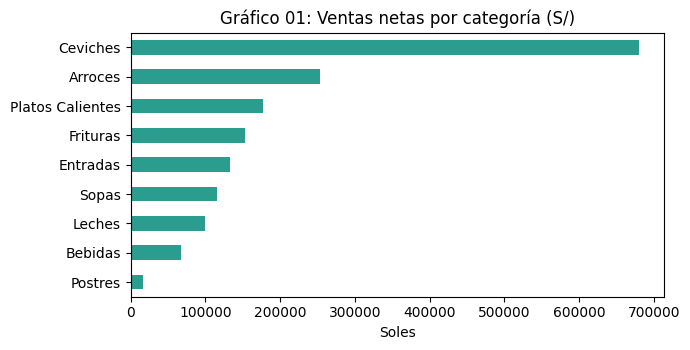

In [ ]:
import matplotlib; import matplotlib.pyplot as plt, seaborn as sns
GR = f'{ROOT}/06_BigData_Spark/graficos'; os.makedirs(GR, exist_ok=True)
%matplotlib inline
p1 = fa.groupBy('categoria').agg(sum('ventas_netas').alias('ventas')).orderBy('ventas').toPandas()
ax = p1.plot(kind='barh', x='categoria', y='ventas', figsize=(7,3.6), color='#2A9D8F', legend=False); ax.set_title('Gráfico 01: Ventas netas por categoría (S/)'); ax.set_xlabel('Soles'); ax.set_ylabel('')
plt.tight_layout(); plt.savefig(f'{GR}/g01_ventas_categoria.png', dpi=130); plt.show()

/usr/local/lib/python3.12/dist-packages/pyspark/sql/pandas/conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()
/usr/local/lib/python3.12/dist-packages/pyspark/sql/pandas/conversion.py:348: UserWarning: toPandas attempted Arrow optimization because 'spark.sql.execution.arrow.pyspark.enabled' is set to true; however, failed by the reason below:
  [PACKAGE_NOT_INSTALLED] PyArrow >= 18.0.0 must be installed; however, it was not found.
Attempting non-optimization as 'spark.sql.execution.arrow.pyspark.fallback.enabled' is set to true.
  warn(msg)


/usr/local/lib/python3.12/dist-packages/pyspark/sql/pandas/types.py:778: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()


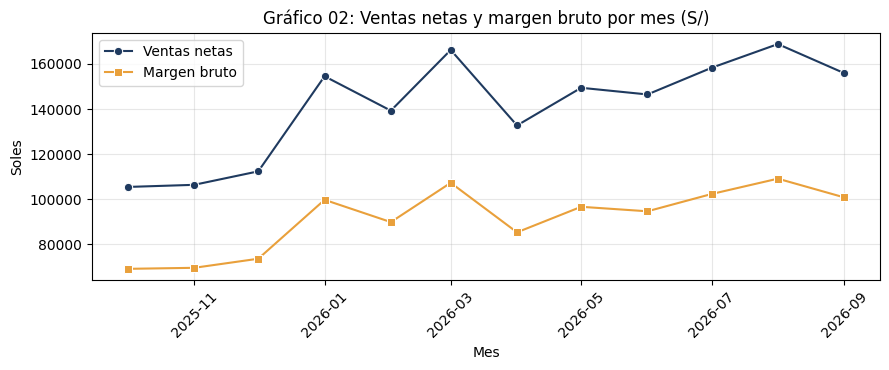

In [ ]:
p2 = fa.groupBy('anio_mes').agg(sum('ventas_netas').alias('ventas'), sum('margen').alias('margen')).orderBy('anio_mes').toPandas()
plt.figure(figsize=(9,3.8)); sns.lineplot(data=p2, x='anio_mes', y='ventas', marker='o', label='Ventas netas', color='#1F3A5F'); sns.lineplot(data=p2, x='anio_mes', y='margen', marker='s', label='Margen bruto', color='#E9A03B')
plt.title('Gráfico 02: Ventas netas y margen bruto por mes (S/)'); plt.xticks(rotation=45); plt.xlabel('Mes'); plt.ylabel('Soles'); plt.grid(True, alpha=.3); plt.tight_layout(); plt.savefig(f'{GR}/g02_ventas_mes.png', dpi=130); plt.show()

/usr/local/lib/python3.12/dist-packages/pyspark/sql/pandas/conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()
/usr/local/lib/python3.12/dist-packages/pyspark/sql/pandas/conversion.py:348: UserWarning: toPandas attempted Arrow optimization because 'spark.sql.execution.arrow.pyspark.enabled' is set to true; however, failed by the reason below:
  [PACKAGE_NOT_INSTALLED] PyArrow >= 18.0.0 must be installed; however, it was not found.
Attempting non-optimization as 'spark.sql.execution.arrow.pyspark.fallback.enabled' is set to true.
  warn(msg)


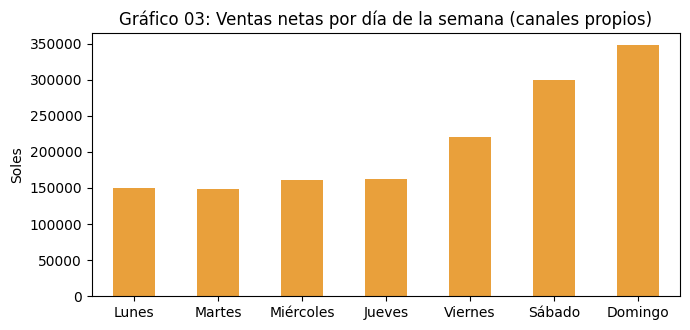

In [17]:
p3 = fa.filter(col('sk_canal')<=3).groupBy('dia_semana').agg(sum('ventas_netas').alias('ventas')).toPandas()
p3['dia_semana'] = p3.dia_semana.astype('category').cat.set_categories(['Lunes','Martes','Miércoles','Jueves','Viernes','Sábado','Domingo'], ordered=True); p3 = p3.sort_values('dia_semana')
p3.plot(kind='bar', x='dia_semana', y='ventas', figsize=(7,3.4), color='#E9A03B', legend=False); plt.title('Gráfico 03: Ventas netas por día de la semana (canales propios)'); plt.xlabel(''); plt.ylabel('Soles'); plt.xticks(rotation=0)
plt.tight_layout(); plt.savefig(f'{GR}/g03_ventas_dia.png', dpi=130); plt.show()

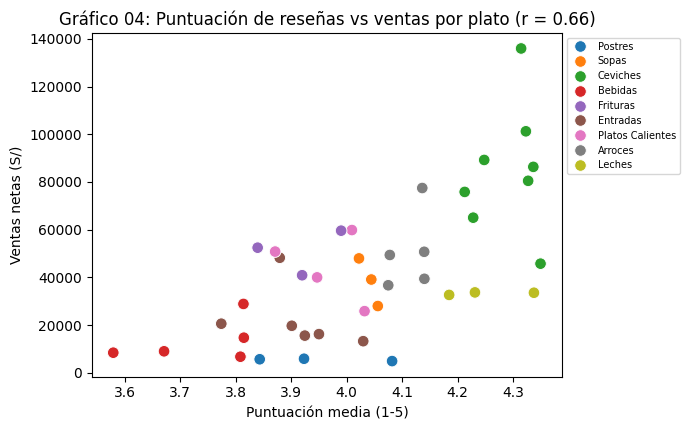

In [18]:
plt.figure(figsize=(7,4.4)); sns.scatterplot(data=cp, x='puntuacion_media', y='ventas', hue='categoria', s=70); plt.title(f'Gráfico 04: Puntuación de reseñas vs ventas por plato (r = {corr:.2f})')
plt.xlabel('Puntuación media (1-5)'); plt.ylabel('Ventas netas (S/)'); plt.legend(fontsize=7, bbox_to_anchor=(1,1)); plt.tight_layout(); plt.savefig(f'{GR}/g04_resenas_vs_ventas.png', dpi=130); plt.show()

## 8. Rendimiento y escalabilidad: Spark vs pandas vs motor SQL (SQLite)
Se replica la tabla de hechos ×1, ×10 y ×50 (hasta ≈ 2 millones de filas) y se mide la misma agregación (ventas netas por plato y canal con *join* a la dimensión). Se toma la **mediana de 3 ejecuciones**, con datos ya cargados en memoria/tabla (Spark: `cache()`). Además se mide Spark de extremo a extremo desde el CSV. *SQL Server se mide con `11_Benchmark_SQLServer.sql` sobre el mismo DW y se anota en el informe.*

In [19]:
import pandas as pd, numpy as np, sqlite3, time, statistics as st, gc
base = pd.read_csv(f'{DW}/fact_ventas.csv', usecols=['sk_plato','sk_canal','importe_neto','cantidad'])
dp = pd.read_csv(f'{DW}/dim_plato.csv', usecols=['sk_plato','nombre_plato'])
def med(fn, n=3):
    ts=[]
    for _ in range(n):
        t=time.perf_counter(); fn(); ts.append(time.perf_counter()-t)
    return st.median(ts)
res_b=[]
for k in [1,10,50]:
    big = pd.concat([base]*k, ignore_index=True); n=len(big)
    # pandas
    t_pd = med(lambda: big.merge(dp,on='sk_plato').groupby(['nombre_plato','sk_canal']).agg(v=('importe_neto','sum'), u=('cantidad','sum')))
    # SQLite (motor relacional de referencia, con índice en la FK)
    db = sqlite3.connect(':memory:'); big.to_sql('f', db, index=False); dp.to_sql('p', db, index=False); db.execute('CREATE INDEX ix ON f(sk_plato)')
    t_sql = med(lambda: db.execute('SELECT p.nombre_plato,f.sk_canal,SUM(f.importe_neto),SUM(f.cantidad) FROM f JOIN p ON p.sk_plato=f.sk_plato GROUP BY 1,2').fetchall()); db.close()
    # Spark (datos en memoria)
    sdf = spark.createDataFrame(big).cache(); sdf.count(); sdp = spark.createDataFrame(dp)
    t_sp = med(lambda: sdf.join(sdp,'sk_plato').groupBy('nombre_plato','sk_canal').agg(sum('importe_neto'),sum('cantidad')).collect())
    sdf.unpersist(); del big; gc.collect()
    res_b.append(dict(filas=n, pandas_s=round(t_pd,3), sqlite_s=round(t_sql,3), spark_s=round(t_sp,3)))
    print(res_b[-1])
bench = pd.DataFrame(res_b); bench

/usr/local/lib/python3.12/dist-packages/pyspark/sql/pandas/conversion.py:659: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()
/usr/local/lib/python3.12/dist-packages/pyspark/sql/pandas/conversion.py:936: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()
/usr/local/lib/python3.12/dist-packages/pyspark/sql/pandas/conversion.py:687: UserWarning: createDataFrame attempted Arrow optimization because 'spark.sql.execution.arrow.pyspark.enabled' is set to true; however, failed by the reason below:
  [PACKAGE_NOT_INSTALLED] PyArrow >= 18.0.0 must be installed; however, it was not found.
Attempting non-optimization as 'spark.sql.execution.arrow.pyspark.fallback.enabled' is set to true.
  warn(msg)


{'filas': 40867, 'pandas_s': 0.013, 'sqlite_s': 0.033, 'spark_s': 0.707}


/usr/local/lib/python3.12/dist-packages/pyspark/sql/pandas/conversion.py:659: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()
/usr/local/lib/python3.12/dist-packages/pyspark/sql/pandas/conversion.py:936: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()
/usr/local/lib/python3.12/dist-packages/pyspark/sql/pandas/conversion.py:687: UserWarning: createDataFrame attempted Arrow optimization because 'spark.sql.execution.arrow.pyspark.enabled' is set to true; however, failed by the reason below:
  [PACKAGE_NOT_INSTALLED] PyArrow >= 18.0.0 must be installed; however, it was not found.
Attempting non-optimization as 'spark.sql.execution.arrow.pyspark.fallback.enabled' is set to true.
  warn(msg)


{'filas': 408670, 'pandas_s': 0.099, 'sqlite_s': 0.363, 'spark_s': 0.913}


/usr/local/lib/python3.12/dist-packages/pyspark/sql/pandas/conversion.py:659: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()
/usr/local/lib/python3.12/dist-packages/pyspark/sql/pandas/conversion.py:936: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()
/usr/local/lib/python3.12/dist-packages/pyspark/sql/pandas/conversion.py:687: UserWarning: createDataFrame attempted Arrow optimization because 'spark.sql.execution.arrow.pyspark.enabled' is set to true; however, failed by the reason below:
  [PACKAGE_NOT_INSTALLED] PyArrow >= 18.0.0 must be installed; however, it was not found.
Attempting non-optimization as 'spark.sql.execution.arrow.pyspark.fallback.enabled' is set to true.
  warn(msg)


{'filas': 2043350, 'pandas_s': 0.421, 'sqlite_s': 2.251, 'spark_s': 1.691}


,filas,pandas_s,sqlite_s,spark_s
0,40867,0.013,0.033,0.707
1,408670,0.099,0.363,0.913
2,2043350,0.421,2.251,1.691


Extremo a extremo (40 867 filas, desde CSV): Spark 0.76 s | pandas 0.14 s


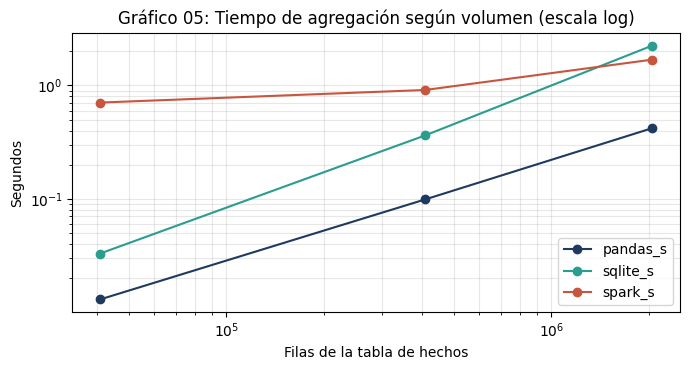

In [20]:
# Spark extremo a extremo (leer CSV + agregar) sobre el CSV original del DW
t=time.perf_counter(); fact.join(d_plato.select('sk_plato','nombre_plato'),'sk_plato').groupBy('nombre_plato','sk_canal').agg(sum('ventas_netas')).collect(); t_e2e=time.perf_counter()-t
t=time.perf_counter(); pd.read_csv(f'{DW}/fact_ventas.csv').merge(dp,on='sk_plato').groupby(['nombre_plato','sk_canal']).importe_neto.sum(); t_e2e_pd=time.perf_counter()-t
print(f'Extremo a extremo (40 867 filas, desde CSV): Spark {t_e2e:.2f} s | pandas {t_e2e_pd:.2f} s')
bench['sql_vs_spark_x'] = (bench.spark_s/bench.sqlite_s).round(2)
bench.to_csv(f'{ROOT}/06_BigData_Spark/benchmark_tiempos.csv', index=False)
ax = bench.set_index('filas')[['pandas_s','sqlite_s','spark_s']].plot(marker='o', figsize=(7,3.8), logx=True, logy=True, color=['#1F3A5F','#2A9D8F','#C8553D'])
ax.set_title('Gráfico 05: Tiempo de agregación según volumen (escala log)'); ax.set_xlabel('Filas de la tabla de hechos'); ax.set_ylabel('Segundos'); ax.grid(True, which='both', alpha=.3)
plt.tight_layout(); plt.savefig(f'{GR}/g05_benchmark.png', dpi=130); plt.show()

## 9. Análisis de eficiencia, escalabilidad y adecuación

In [ ]:
import builtins
from IPython.display import Markdown
mx = builtins.max
b = bench.iloc[-1]; a = bench.iloc[0]
Markdown(f'''**Resultados medidos en este entorno ({sc.defaultParallelism} núcleo/s, Spark {spark.version}, modo local):**

* Con **{int(a.filas):,} filas** (volumen real del negocio, un año de ventas) pandas tarda {a.pandas_s} s, SQLite {a.sqlite_s} s y Spark {a.spark_s} s: Spark es ≈ **{a.spark_s/mx(a.sqlite_s,1e-3):.0f}×** más lento que el motor relacional porque paga costos fijos de JVM, planificación (Catalyst), *shuffle* y serialización.
* Con **{int(b.filas):,} filas** (×50) pandas tarda {b.pandas_s} s, SQLite {b.sqlite_s} s y Spark {b.spark_s} s. La relación Spark/SQLite pasa de {a.spark_s/mx(a.sqlite_s,1e-3):.0f}× a {b.spark_s/mx(b.sqlite_s,1e-3):.1f}×: el costo fijo se amortiza y la curva de Spark crece más despacio.
* En un solo núcleo Spark no puede mostrar su ventaja principal (paralelismo horizontal). Su punto de cruce aparece cuando hay **varios núcleos/nodos** y volúmenes que no caben en la memoria de un solo equipo.
* **Conclusión de adecuación:** para una cevichería (≈ 12 mil pedidos/año) la solución adecuada es **SQL Server + Power BI**; Spark se justifica como componente de **escalabilidad futura** (cadena de locales, integración de reseñas y apps, análisis de texto) y por la lectura nativa de JSON semiestructurado. Correlación reseñas–ventas por plato: r = {corr:.2f}.''')

**Resultados medidos en este entorno (1 núcleo/s, Spark 4.2.0, modo local):**

* Con **40,867 filas** (volumen real del negocio, un año de ventas) pandas tarda 0.013 s, SQLite 0.033 s y Spark 0.707 s: Spark es ≈ **21×** más lento que el motor relacional porque paga costos fijos de JVM, planificación (Catalyst), *shuffle* y serialización.
* Con **2,043,350 filas** (×50) pandas tarda 0.421 s, SQLite 2.251 s y Spark 1.691 s. La relación Spark/SQLite pasa de 21× a 0.8×: el costo fijo se amortiza y la curva de Spark crece más despacio.
* En un solo núcleo Spark no puede mostrar su ventaja principal (paralelismo horizontal). Su punto de cruce aparece cuando hay **varios núcleos/nodos** y volúmenes que no caben en la memoria de un solo equipo.
* **Conclusión de adecuación:** para una cevichería (≈ 12 mil pedidos/año) la solución adecuada es **SQL Server + Power BI**; Spark se justifica como componente de **escalabilidad futura** (cadena de locales, integración de reseñas y apps, análisis de texto) y por la lectura nativa de JSON semiestructurado. Correlación reseñas–ventas por plato: r = 0.66.

### Cuándo usar cada tecnología
| Condición | Solución recomendada | Motivo |
|---|---|---|
| ≤ millones de filas, consultas repetitivas, transacciones y seguridad por roles | SQL Server (con índices / columnstore) | latencia baja, ACID, RLS/DDM, auditoría |
| Análisis exploratorio en un equipo, hasta unos millones de filas | pandas | más simple y rápido si cabe en RAM |
| Cientos de millones de filas, varios nodos, JSON/CSV/Parquet heterogéneos | Apache Spark | paralelismo, *lazy evaluation*, esquema flexible |